# This file plots a time series of AMOC extracted at 40°N

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages(import_spline=False))
misc_params = Params.additional_misc_params()

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = True
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the variable (AMOC)

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'msftyz'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the AMOC datasets

In [5]:
def _extract_Atlantic_Arctic_streamfunction(run_params,key,ds):

    # get the model name
    model = run_params[key].model

    # identify the basin index for each model (each model dataset a bit different - inferred from looking at each dataset)
    if model == 'UKESM1-0-LL':
        bdx = np.where(ds.sector.values == b'atlantic_arctic_ocean')[0]
    elif model == 'NorESM2-LM':
        bdx = 0  #ds_str[key].sector=='atlantic_arctic_ocean'
    elif model == 'CNRM-ESM2-1':
        bdx = np.where(ds.sector.values == b'atlantic_arctic_ocean')[0]   # 1
    elif model == 'CESM2':
        bdx = 0  #ds_str[key].basin==0 #1
    elif model == 'MIROC-ES2L':
        bdx = np.where(ds.sector.values == b'atlantic_arctic_ocean')[0]
    elif model == 'ACCESS-ESM1-5':
        bdx = np.where(ds.sector.values == b'atlantic_arctic_ocean')[0]
    elif model == 'CanESM5':
        bdx = np.where(ds.sector.values == b'atlantic_arctic_ocean')[0]
    elif model == 'GFDL-ESM4':
        bdx = np.where(ds.region.values == b'atlantic_arctic_ocean          ')[0]
    
    da = ds.isel(basin=bdx)    

    # get the dataset
    if 'msftyz' in list(da.variables):
        streamfunction = da.msftyz
    elif 'msftmz' in list(da.variables):
        streamfunction = da.msftmz  
    
    return streamfunction.load() 

def _extract_streamfunction_value_at_certain_latitude(streamfunction,lat_of_choice=40):

    if 'lat' in list(streamfunction.coords):
        stream_lat = streamfunction.sel(lat=lat_of_choice,method='nearest')
    elif 'rlat' in list(streamfunction.coords):
        stream_lat = streamfunction.sel(rlat=lat_of_choice,method='nearest')
    elif 'y' in list(streamfunction.coords):
        stream_lat = streamfunction.sel(y=lat_of_choice,method='nearest')
    elif 'j-mean' in list(streamfunction.coords):
        if lat_of_choice == 26.5:
            jmeanval = 191
        elif lat_of_choice == 40:
            jmeanval = 208   # ranging from 207-211, i.e. 207:212
        else:
            raise Exception('Not yet implemented for other latitudes.')
        stream_lat = streamfunction.isel(**{'j-mean': jmeanval})      # or **{'j-mean': slice(207,212)}).mean(dim='j-mean')
    else:
        print(f'Latitude variable not recognized for key {key}')
        print(list(streamfunction.coords))
    
    return stream_lat

def _find_maximum_across_depth(streamfunction_at_latitude_y,mask_shallow_depths_until_Xm=500):

    # mask the upper {mask_shallow_depths_until_Xm} meter
    if streamfunction_at_latitude_y['lev'].mean(dim='lev')>0:
        masked = xr.where(streamfunction_at_latitude_y.lev > mask_shallow_depths_until_Xm, streamfunction_at_latitude_y, np.NaN)
    elif streamfunction_at_latitude_y['lev'].mean(dim='lev')<0:
        masked = xr.where(streamfunction_at_latitude_y.lev < (-1*mask_shallow_depths_until_Xm), streamfunction_at_latitude_y, np.NaN)

    #print(streamfunction_at_latitude_y)
    streamfunction_value = masked.max('lev')
    streamfunction_lev_argmax = masked.argmax('lev')
    streamfunction_lev = streamfunction_at_latitude_y['lev'][streamfunction_lev_argmax]

    #print(streamfunction_value, streamfunction_lev_argmax)
    return streamfunction_value, streamfunction_lev



def _get_AMOC_time_series(run_params,variable_to_analyze,temporal_resolution, latitude_of_choice=40, mask_shallow_depths_until_Xm=500):

    root_path = f'/data/ekoehn/CMIP6_derived/{variable_to_analyze}'
    rampup_path = f'{root_path}/1pctCO2/Omon'
    rampdn_path = f'{root_path}/1pctCO2-cdr/Omon'

    streamfunction_dict = dict()
    streamfunction_lev_dict = dict()
    
    for key in run_params.keys():

        print(f'Processing the data and calculating AMOC for {latitude_of_choice}°N for {run_params[key].model} .......')
        
        # identify the filenames
        rampup_filename = glob.glob(f'{rampup_path}/*{run_params[key].model}*.nc')[0]
        rampdn_filename = glob.glob(f'{rampdn_path}/*{run_params[key].model}*.nc')[0]

        # open the rampup and rampdown files
        with xr.open_dataset(rampup_filename) as ds_rampup , xr.open_dataset(rampdn_filename) as ds_rampdn:

            if run_params[key].model == 'MIROC-ES2L':
                numyears = 139 
            elif run_params[key].model == 'CanESM5':
                numyears = 141
            else:
                numyears = 140
            months_per_year = 12

            # the rampup
            ds_rampup = ds_rampup.isel(time=slice(0,numyears*months_per_year))
            new_time = pd.date_range("1850-01-01", periods=len(ds_rampup.time), freq="MS")  # yearly starts
            ds_rampup['time'] = new_time
            ds_rampup = ds_rampup#.load()

            # the rampdown
            ds_rampdn = ds_rampdn.isel(time=slice(0,(340-numyears)*months_per_year))
            new_time = pd.date_range(f"{1850+numyears}-01-01", periods=len(ds_rampdn.time), freq="MS")  # yearly starts
            ds_rampdn['time'] = new_time
            ds_rampdn = ds_rampdn#.load()

            # concatenate them and get the annual means
            if temporal_resolution == 'annual_means':
                ds = xr.concat([ds_rampup,ds_rampdn],dim='time').groupby('time.year').mean('time')
            else:
                raise Exception('other temporal resolution not yet implemented.')

            # extract the Atlantic+Arctic overturning streamfunction
            atlantic_streamfunction = _extract_Atlantic_Arctic_streamfunction(run_params,key,ds)

            # extract AMOC at certain latitude
            streamfunction_at_latitude_y = _extract_streamfunction_value_at_certain_latitude(atlantic_streamfunction,lat_of_choice=latitude_of_choice)

            # search for maximum across depth
            streamfunction_dict[key], streamfunction_lev_dict[key] = _find_maximum_across_depth(streamfunction_at_latitude_y,mask_shallow_depths_until_Xm=mask_shallow_depths_until_Xm)

            # convert from kg s-1 to Sv using a constant density of 1035kg m-3
            const_dens = 1035 #kg m-3
            factor_m3_per_s_to_Sv = 1/10**6 # 10^6 m3 s-1 = 1Sv
            streamfunction_dict[key] = streamfunction_dict[key]/const_dens * factor_m3_per_s_to_Sv

    # some final cleaning
    for key in run_params.keys():
        streamfunction_dict[key] = streamfunction_dict[key].squeeze()
        streamfunction_lev_dict[key] = streamfunction_lev_dict[key].squeeze()
    for key in run_params.keys():
        if 'rlat' in streamfunction_dict[key].coords:
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('rlat', drop=True)
        elif 'lat' in streamfunction_dict[key].coords: 
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('lat', drop=True)
        elif 'j-mean' in streamfunction_dict[key].coords: 
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('j-mean', drop=True)
        elif 'y' in streamfunction_dict[key].coords: 
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('y', drop=True)
        else:
            print('did not work')
        if 'sector' in streamfunction_dict[key].coords:
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('sector', drop=True)
        elif 'region' in streamfunction_dict[key].coords:
            streamfunction_dict[key] = streamfunction_dict[key].reset_coords('region', drop=True)

    return streamfunction_dict, streamfunction_lev_dict

print('Get a dictionary with all AMOC time series......')

latitude_of_choice = 40
mask_shallow_depths_until_Xm = 500
streamfunction_dict, streamfunction_lev_dict =  _get_AMOC_time_series(run_params,variable_to_analyze,temporal_resolution,latitude_of_choice = latitude_of_choice, mask_shallow_depths_until_Xm = mask_shallow_depths_until_Xm)

Get a dictionary with all AMOC time series......
Processing the data and calculating AMOC for 40°N for UKESM1-0-LL .......
Processing the data and calculating AMOC for 40°N for NorESM2-LM .......
Processing the data and calculating AMOC for 40°N for MIROC-ES2L .......
Processing the data and calculating AMOC for 40°N for CNRM-ESM2-1 .......
Processing the data and calculating AMOC for 40°N for ACCESS-ESM1-5 .......
Processing the data and calculating AMOC for 40°N for CESM2 .......
Processing the data and calculating AMOC for 40°N for CanESM5 .......
Processing the data and calculating AMOC for 40°N for GFDL-ESM4 .......


## Make the time series plot

calculate the multi-model mean and plot the results.....


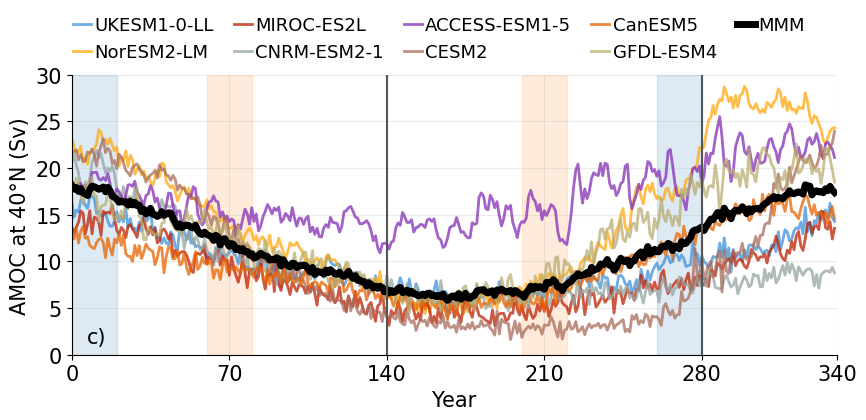

In [6]:
print('calculate the multi-model mean and plot the results.....')
fig, ax = Plotter._plot_regional_time_series_without_smoothing(run_params,streamfunction_dict,'_no_region_',unit_label=f'AMOC at {latitude_of_choice}°N (Sv)',ylims=[0,30],panellabel='c)')#,ylims=[-30,80])
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_time_1region_fancy_{"AMOC"}.png',dpi=300,transparent=True)

## Compute the hysteresis area

In [7]:
print('Compute the hysteresis area for AMOC......')
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)

h_amoc_hn = xr.Dataset()
h_amoc_hs = xr.Dataset()
h_amoc = HystFuncs._calc_hysteresis_areas_1D_multimodel(run_params,
                                                            streamfunction_dict,
                                                            temporal_resolution,
                                                            ds_atmCO2,
                                                            normalizer='min_max_diff_full_cycle',
                                                            nsteps=200,
                                                            return_interpolated_vectors=False
                                                            )

# Reorganize the output into hysteresis area xr.Datasets
for key in run_params.keys():
    h_amoc_hn[key] = xr.DataArray(h_amoc[key][2])#,name='normalized hysteresis area')
    h_amoc_hs[key] = xr.DataArray(h_amoc[key][1])#,name='signed hysteresis area')

h_amoc_hn.attrs['unit'] = 'ppm'
h_amoc_hn.attrs['name'] = 'normalized hysteresis area'
h_amoc_hn.attrs['AMOC_notes'] = f'lat_of_choice: {latitude_of_choice}, masking until Xm: {mask_shallow_depths_until_Xm}'

h_amoc_hs.attrs['unit'] = 'Sv'
h_amoc_hs.attrs['name'] = 'signed hysteresis area'
h_amoc_hs.attrs['AMOC_notes'] = f'lat_of_choice: {latitude_of_choice}, masking until Xm: {mask_shallow_depths_until_Xm}'



Compute the hysteresis area for AMOC......
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking in

## Save the AMOC hysteresis areas

In [8]:
############### SAVE THE AMOC hysteresis areas #################
h_amoc_hn.to_netcdf(f'../05_plots_datasets/fig04_AMOC_{latitude_of_choice}N_normalized_hysteresis_area.nc')
h_amoc_hs.to_netcdf(f'../05_plots_datasets/fig04_AMOC_{latitude_of_choice}N_signed_hysteresis_area.nc')